# Understanding CNNs: From Pixels to Features

This notebook provides foundational understanding of how Convolutional Neural Networks (CNNs) process and interpret visual data. While this project focuses on vision interpretability rather than teaching CNNs from scratch, most interpretability techniques assume a clear mental model of CNN operations.

## Key Concepts Covered

1. **First Impressions of Data**: How raw images are loaded and what CNNs initially "see"
2. **Local Pattern Detection**: How convolutional filters act as local feature detectors
3. **Spatial Locality & Weight Sharing**: The fundamental principles behind convolution operations
4. **Progressive Abstraction**: How increasing depth creates hierarchical feature representations

Understanding these concepts is essential for interpreting CNN behavior and avoiding common misinterpretations of interpretability results.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

## Setup: Import Required Libraries

In [2]:
# Load CIFAR-10 dataset (auto-downloads ~170 MB)
# CIFAR-10 contains 50,000 training images of 32×32 pixels across 10 classes
dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=None   # Load raw PIL images first
)

# Pick an image to explore (you can change index to any number 0–49999)
img_index = 1
pil_image, label = dataset[img_index]

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Original image is a {class_names[label]} ({pil_image.size})")

Original image is a truck ((32, 32))


## 1. First Impressions: What CNNs Initially "See"

Before diving into interpretability, we need to understand what data looks like when it enters a CNN. We'll use CIFAR-10, a classic dataset of 32×32 color images across 10 categories.

**Key Insight**: CNNs don't "see" images the way humans do. They process numerical arrays where each pixel is represented as intensity values. Understanding this data representation is crucial for interpreting CNN behavior.

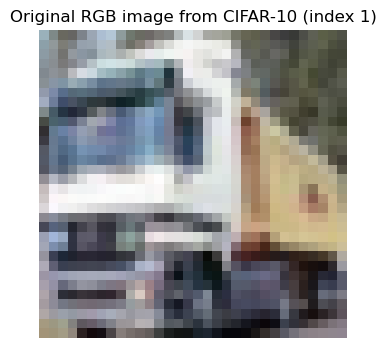

In [3]:
# Display the original RGB color image as humans see it
plt.figure(figsize=(4, 4))
plt.imshow(pil_image)
plt.title(f"Original RGB image from CIFAR-10 (index {img_index})")
plt.axis('off')
plt.show()

In [4]:
# Convert RGB image to grayscale (single channel)
transform_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # 1 channel → true grayscale
    transforms.ToTensor()                         # PIL → torch.Tensor [0,1]
])

gray_tensor = transform_gray(pil_image)

print("Grayscale tensor shape:", gray_tensor.shape)          # Expected: torch.Size([1, 32, 32])
print("Data type:", gray_tensor.dtype)                       # torch.float32
print("Min / Max pixel value:", gray_tensor.min().item(), "–", gray_tensor.max().item())
print("Mean pixel value:", gray_tensor.mean().item())

Grayscale tensor shape: torch.Size([1, 32, 32])
Data type: torch.float32
Min / Max pixel value: 0.0235294122248888 – 0.9921568632125854
Mean pixel value: 0.5110753774642944


## 2. From Human Vision to CNN Input: The Numerical Representation

While we see colors and objects, CNNs process **numerical arrays**. Let's convert our image to grayscale to see the fundamental representation that early CNN layers work with.

**Key Concepts**:
- Each pixel becomes a number (0 = black, 1 = white)
- The image is a 2D array of these numbers
- This is what the first convolutional layer receives
- Spatial relationships are preserved in the array structure

In [5]:
# Show the raw numerical representation (what CNN actually processes)
gray_numpy = gray_tensor.squeeze(0).numpy()   # remove channel dim → (32,32)
print("Grayscale image as 2D NumPy array (32×32) – first 8×8 corner:")
print(gray_numpy[:8, :8])   # Each number represents a pixel intensity

Grayscale image as 2D NumPy array (32×32) – first 8×8 corner:
[[0.67058825 0.5254902  0.40392157 0.39607844 0.50980395 0.6431373
  0.73333335 0.7647059 ]
 [0.60784316 0.5921569  0.4862745  0.5019608  0.62352943 0.63529414
  0.7254902  0.73333335]
 [0.59607846 0.5647059  0.4509804  0.59607846 0.5803922  0.5568628
  0.7058824  0.7294118 ]
 [0.5686275  0.5529412  0.4745098  0.52156866 0.6117647  0.74509805
  0.8509804  0.87058824]
 [0.5294118  0.5686275  0.5411765  0.7294118  0.85882354 0.8352941
  0.7137255  0.6666667 ]
 [0.5568628  0.5764706  0.5647059  0.654902   0.60784316 0.5372549
  0.43529412 0.44705883]
 [0.6039216  0.5372549  0.41568628 0.39607844 0.4117647  0.3882353
  0.34509805 0.34901962]
 [0.67058825 0.4862745  0.29803923 0.31764707 0.26666668 0.21176471
  0.20784314 0.15294118]]


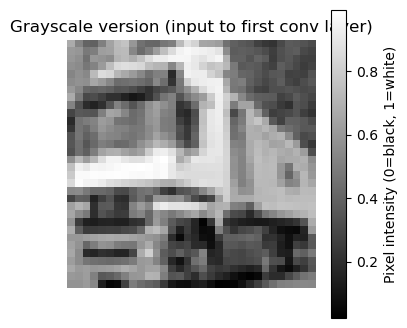

In [6]:
# Visualize the grayscale version
plt.figure(figsize=(4, 4))
plt.imshow(gray_numpy, cmap='gray')
plt.title("Grayscale version (input to first conv layer)")
plt.colorbar(label='Pixel intensity (0=black, 1=white)')
plt.axis('off')
plt.show()

In [7]:
# Convert to numpy for manual convolution
gray_np = gray_tensor.squeeze(0).numpy()  # shape (H, W)

# Define simple 3×3 edge detection filters (like early CNN layers learn)
# Vertical edge detector (Sobel-like): responds to vertical brightness changes
vertical_filter = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=np.float32)

# Horizontal edge detector: responds to horizontal brightness changes
horizontal_filter = np.array([[1, 2, 1],
                              [0, 0, 0],
                              [-1,-2,-1]], dtype=np.float32)

## 3. Convolutional Filters: Local Pattern Detectors

**Core CNN Principle**: Convolutional layers use small filters (kernels) that slide across the image, detecting local patterns like edges, corners, and textures.

**Key Concepts**:
- **Spatial Locality**: Each filter looks at a small neighborhood (e.g., 3×3 pixels)
- **Weight Sharing**: The same filter is applied across the entire image
- **Local Pattern Detection**: Filters respond strongly to specific patterns (vertical edges, horizontal edges, etc.)

We'll manually apply edge detection filters to see how convolution works before CNNs learn these automatically.

In [8]:
# Manual convolution implementation to demonstrate spatial locality
def apply_filter_manual(img, filt):
    """
    Apply a filter to an image using sliding window convolution.
    This demonstrates how CNNs use the same weights (filter) across 
    different spatial locations (weight sharing).
    """
    h, w = img.shape
    fh, fw = filt.shape
    pad_h, pad_w = fh//2, fw//2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros((h, w), dtype=np.float32)
    
    # Slide filter across image (spatial locality + weight sharing)
    for i in range(h):
        for j in range(w):
            patch = padded[i:i+fh, j:j+fw]  # Local neighborhood
            out[i,j] = np.sum(patch * filt)  # Element-wise multiply & sum
    return np.abs(out)

# Apply both edge detectors
vert_edges = apply_filter_manual(gray_np, vertical_filter)
horiz_edges = apply_filter_manual(gray_np, horizontal_filter)

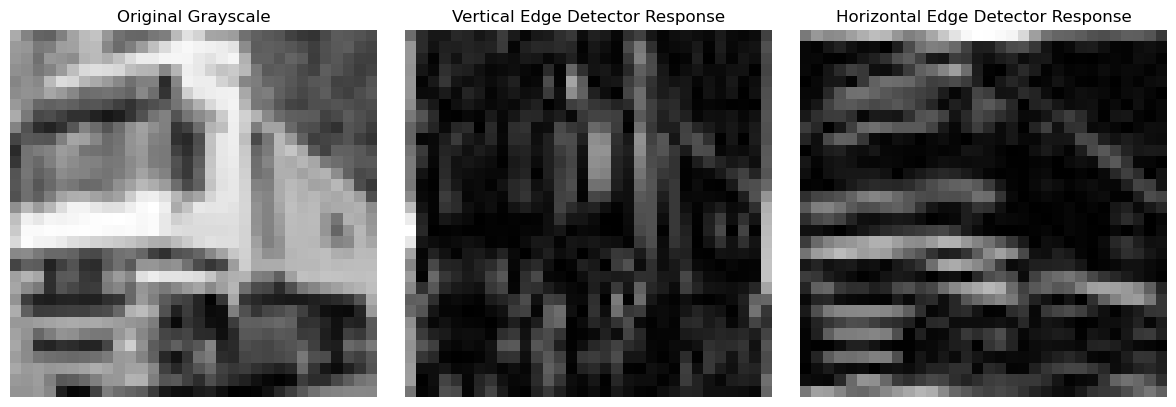


Note: Brighter regions indicate stronger filter response (detected pattern)
This is exactly how the first convolutional layer works, but with learned filters!


In [9]:
# Visualize filter responses
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_np, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[1].imshow(vert_edges, cmap='gray')
axes[1].set_title("Vertical Edge Detector Response")
axes[2].imshow(horiz_edges, cmap='gray')
axes[2].set_title("Horizontal Edge Detector Response")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print("\nNote: Brighter regions indicate stronger filter response (detected pattern)")
print("This is exactly how the first convolutional layer works, but with learned filters!")

In [10]:
# Load a sample ImageNet image for visualization
url = 'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01440764_tench.JPEG'
response = requests.get(url)
pil_image = Image.open(BytesIO(response.content)).convert('RGB')

# Standard ImageNet preprocessing
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = transform(pil_image).unsqueeze(0)  # [1, 3, 224, 224]
print(f"Loaded ImageNet image: {input_tensor.shape}")

Loaded ImageNet image: torch.Size([1, 3, 224, 224])


## 4. Progressive Abstraction: From Edges to High-Level Features

**The Power of Depth**: As we stack convolutional layers, CNNs build increasingly abstract representations:
- **Early layers** (conv1): Detect simple patterns like edges, colors, and textures
- **Middle layers** (inception3a-4a): Combine edges into patterns like corners, curves, and simple shapes  
- **Deeper layers** (inception4e): Detect object parts (eyes, wheels, wings)
- **Deep layers** (inception5b): Recognize high-level concepts and object categories

We'll visualize activations from different depths in InceptionV1 (GoogLeNet) to see this hierarchy in action.

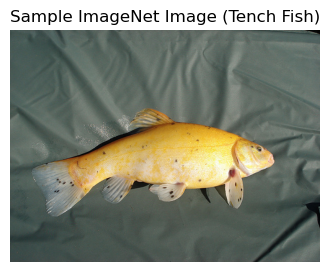

In [11]:
# Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(pil_image)
plt.title("Sample ImageNet Image (Tench Fish)")
plt.axis('off')
plt.show()

Early Layer (conv1): Simple edge and color detectors


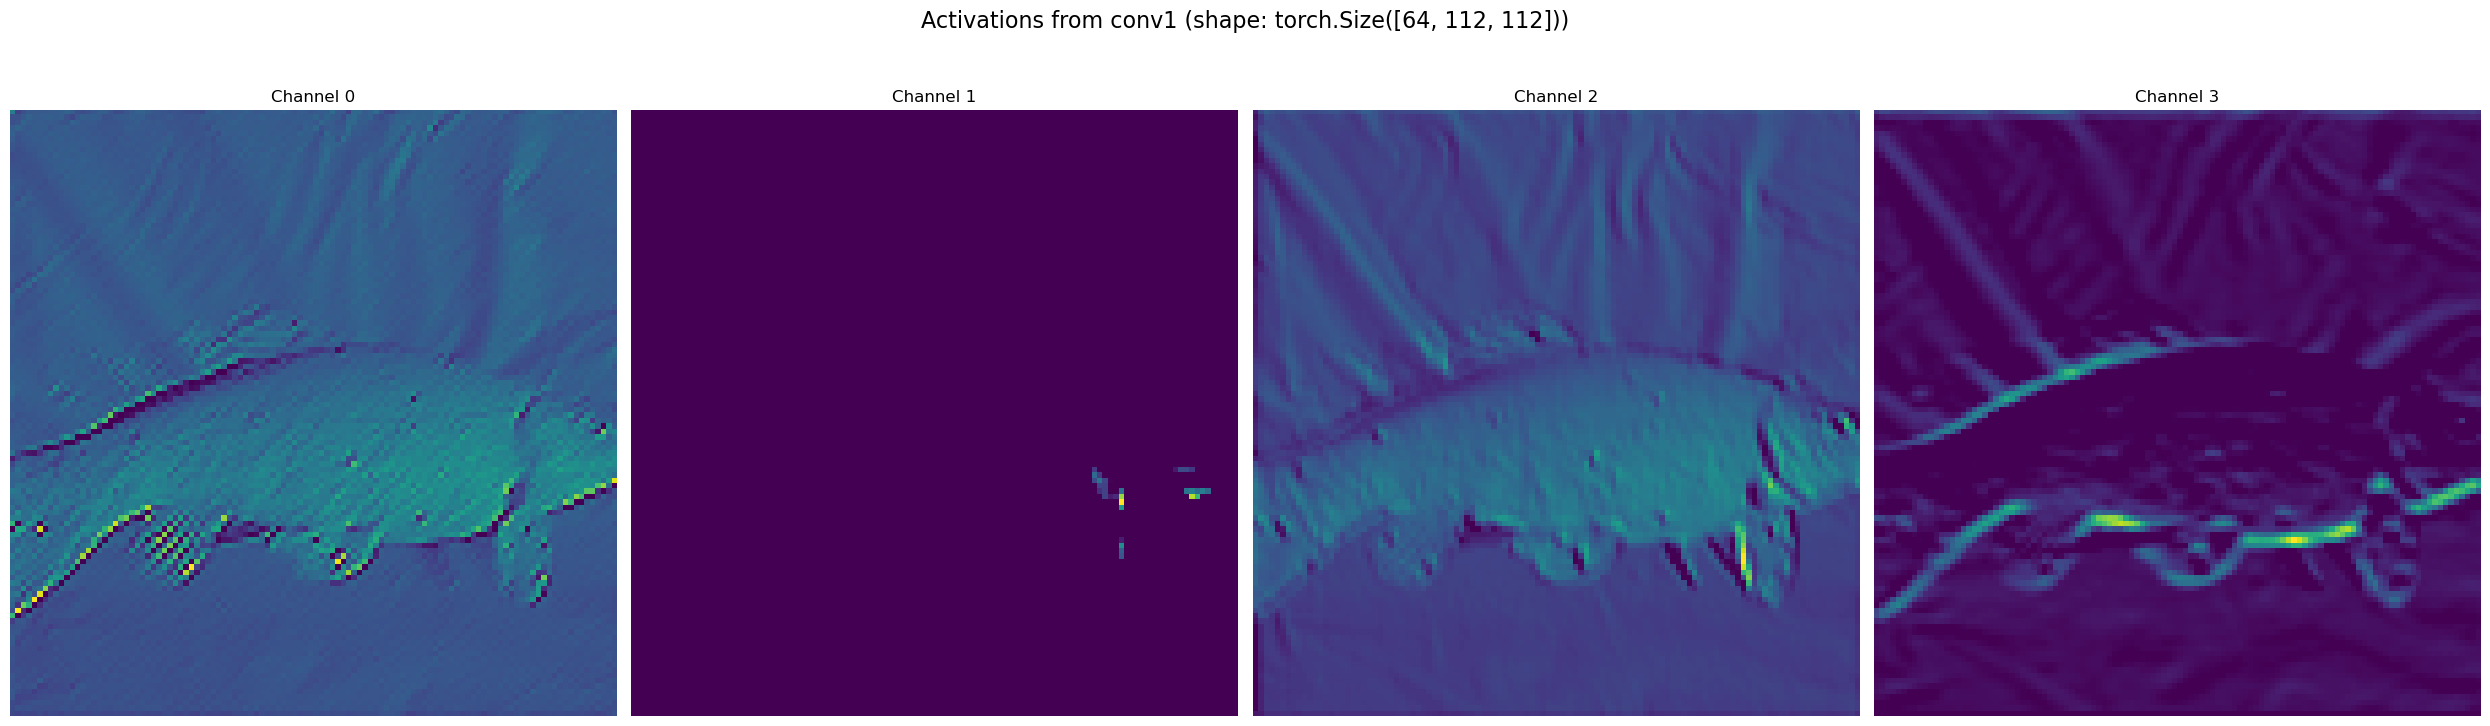


Mid-Early Layer (inception3a): Combining edges into patterns


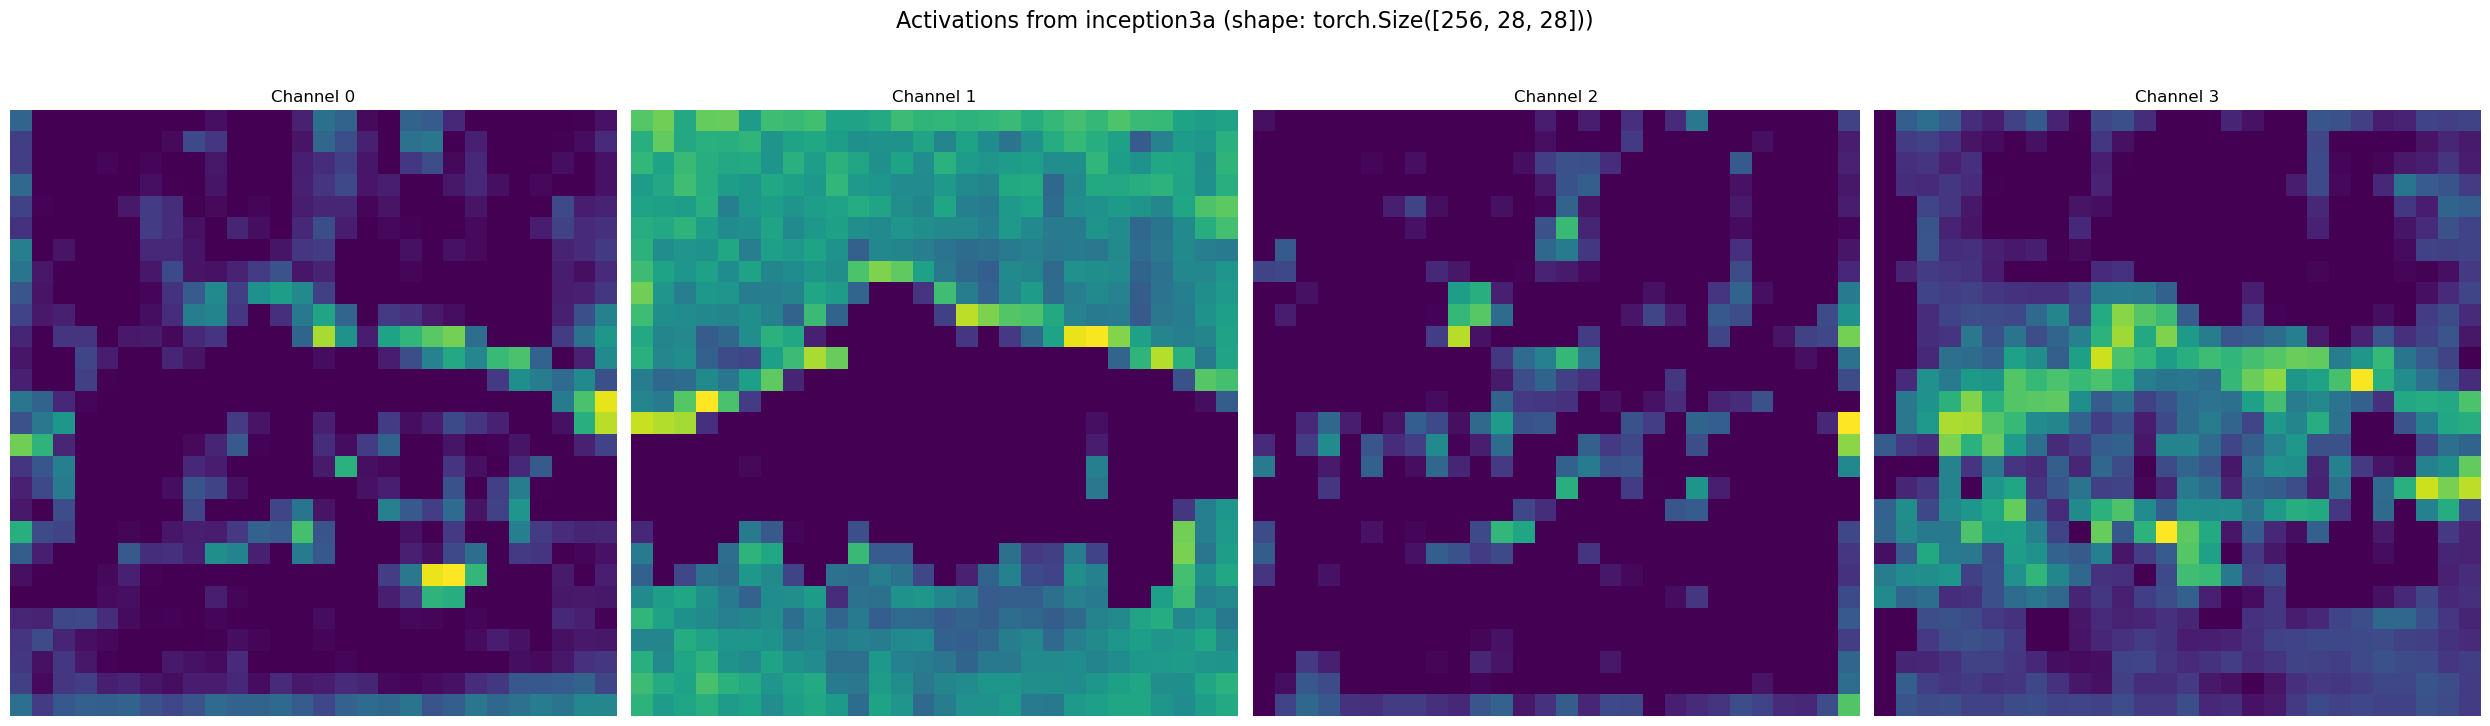


Deeper Layer (inception4e): Abstract patterns and object parts


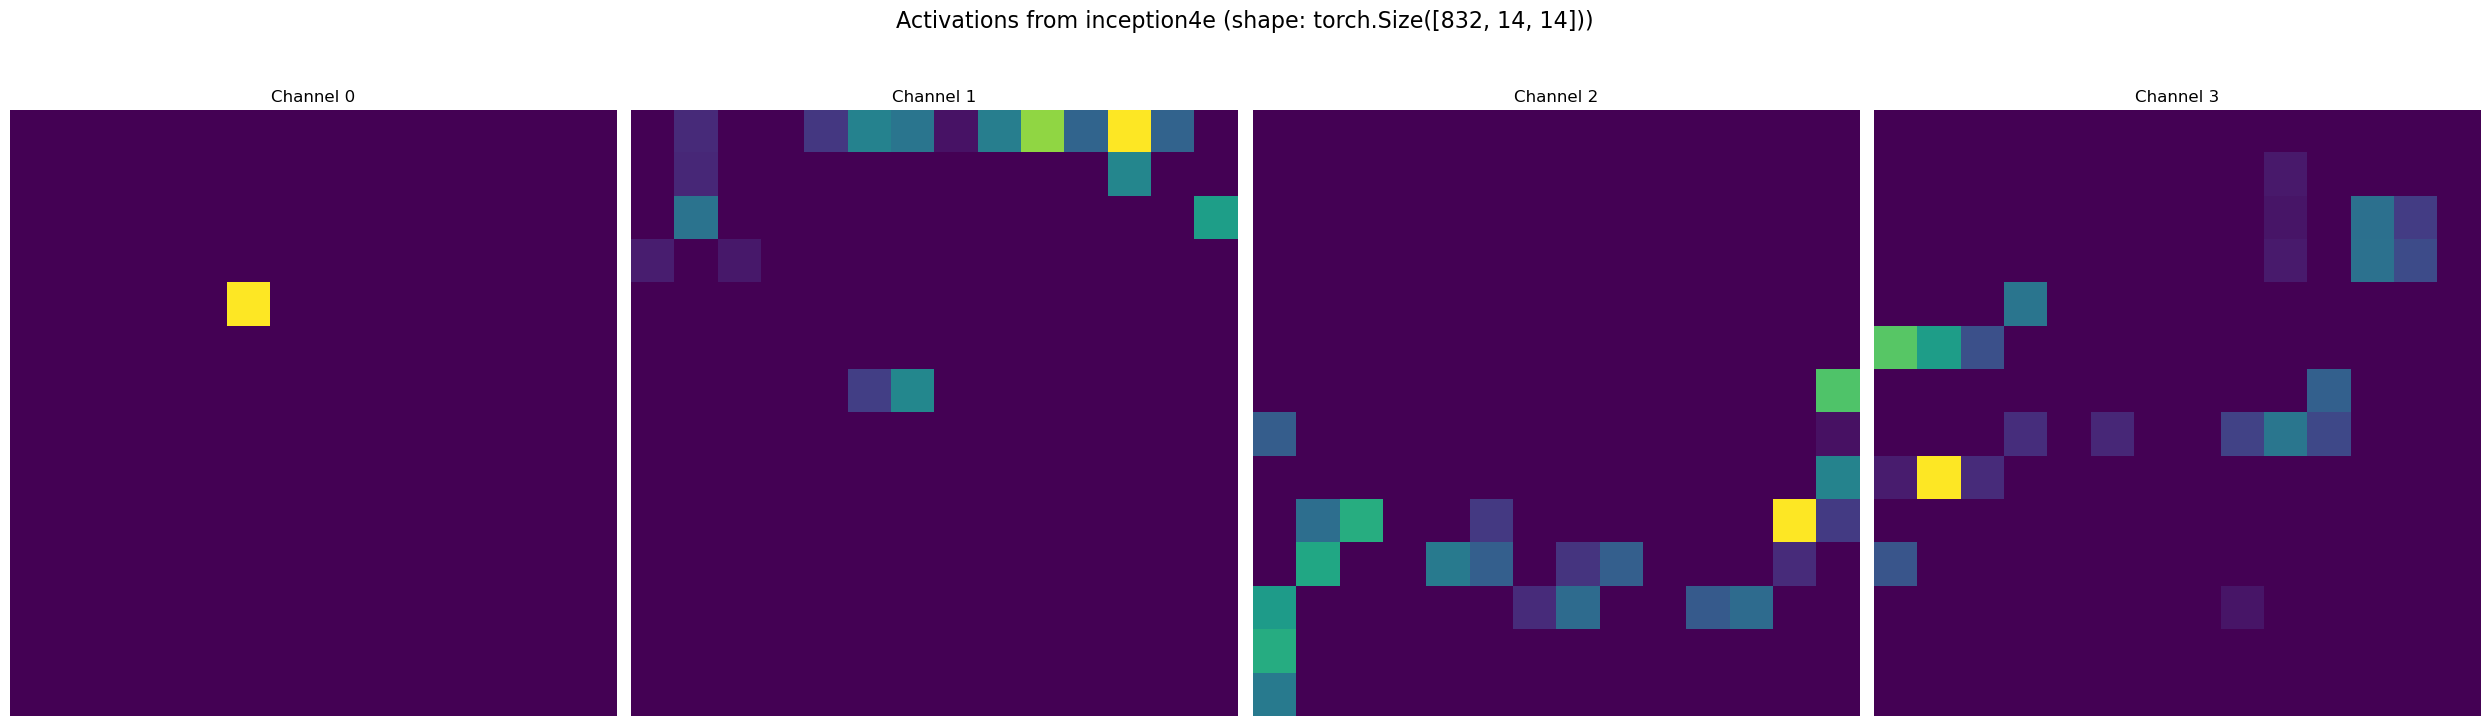


Deep Layer (inception5b): High-level semantic features


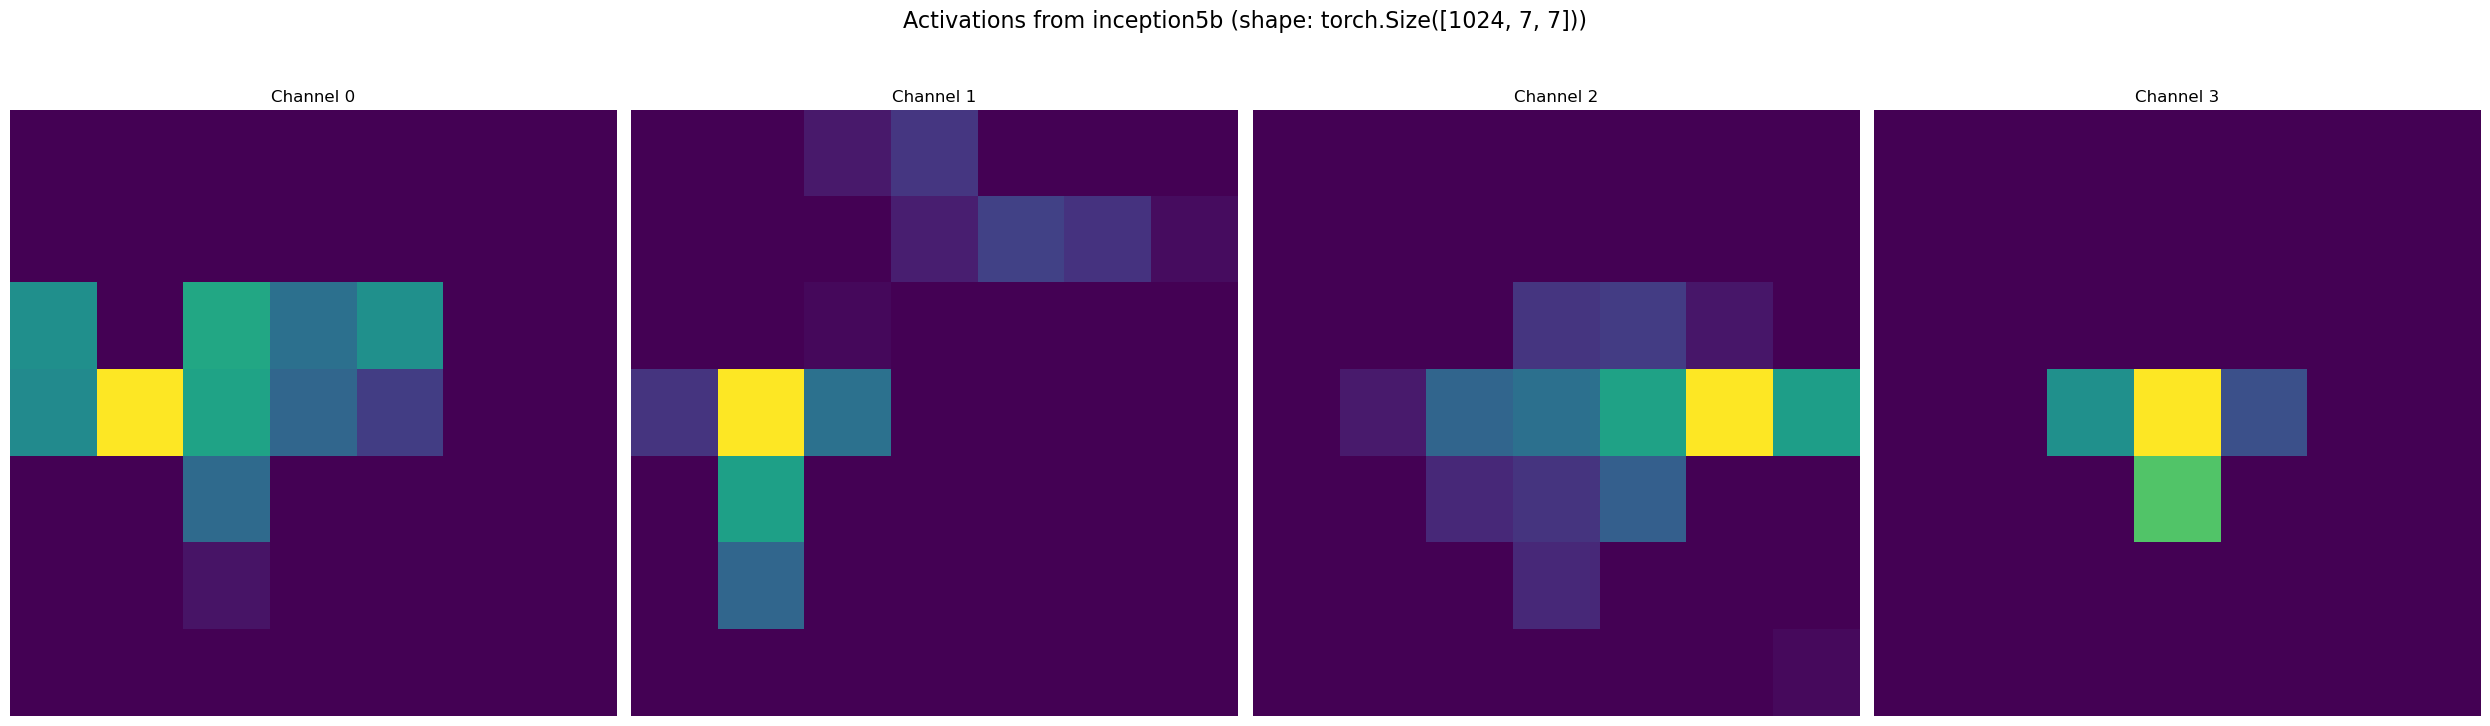

In [12]:
# Load pre-trained InceptionV1 (GoogLeNet) model
model = models.googlenet(weights='GoogLeNet_Weights.DEFAULT').eval()

# Setup hooks to capture intermediate layer activations
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks at different depths to observe progressive abstraction
model.conv1.register_forward_hook(get_activation('conv1'))          # Early: edges, colors
model.inception3a.register_forward_hook(get_activation('inception3a'))  # Mid-early: simple patterns
model.inception4a.register_forward_hook(get_activation('inception4a'))  # Middle: complex patterns
model.inception4e.register_forward_hook(get_activation('inception4e'))  # Deeper: object parts
model.inception5b.register_forward_hook(get_activation('inception5b'))  # Deep: high-level features

# Forward pass to capture activations
with torch.no_grad():
    _ = model(input_tensor)

# Visualization function
def plot_activations(layer_name, num_channels=4):
    """Display activation maps from a specific layer"""
    acts = activations[layer_name][0]  # [C, H, W]
    fig, axes = plt.subplots(1, num_channels, figsize=(25, 8))
    fig.suptitle(f"Activations from {layer_name} (shape: {acts.shape})", fontsize=16)
    for i in range(min(num_channels, acts.shape[0])):
        axes[i].imshow(acts[i].cpu().numpy(), cmap='viridis')
        axes[i].set_title(f"Channel {i}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the hierarchy: early → middle → deep
print("Early Layer (conv1): Simple edge and color detectors")
plot_activations('conv1')

print("\nMid-Early Layer (inception3a): Combining edges into patterns")
plot_activations('inception3a')

print("\nDeeper Layer (inception4e): Abstract patterns and object parts")
plot_activations('inception4e')

print("\nDeep Layer (inception5b): High-level semantic features")
plot_activations('inception5b')

### Observations on Progressive Abstraction

**What to Notice**:
1. **Early layers** show clear spatial structure - you can still "see" the image
2. **Middle layers** become more abstract - recognizable patterns but less image-like
3. **Deep layers** are highly abstract - semantic features divorced from pixel space

This hierarchical feature learning is why CNNs are powerful, and why interpretability at different depths reveals different aspects of the model's "understanding".